# Winter Wheat Phenology: PVTT vs Learned Hybrid

Compares the **Photo-Vernalization Thermal Time (PVTT)** process-based model
with a **WheatHybridModel** — a deep-learning model that shares the same
*two-stage logical structure* as PVTT but learns each functional form from data.

The key inductive bias encoded in the architecture:

    ps = SoftThreshold(cumsum_0) × SoftThreshold(cumsum_1)

Both accumulators must saturate before heading probability rises — mirroring
PVTT where vernalization must complete before PVTT can accumulate.  What each
channel captures (vernalization vs. forcing) is learned, not fixed.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch

from pysephone.constants import KEY_FEATURES, KEY_OBSERVATIONS_INDEX
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures
from pysephone.evaluation.regression import SingleTargetRegression
from pysephone.models.pvtt import PVTTModel
from pysephone.models.wheat_hybrid import WheatHybridModel
from pysephone.models.util.func_phenology import (
    func_vernalization_unit,
    func_vernalization_tres,
    func_photoperiod_factor,
    func_growing_degree_units_2,
)
from pysephone.utils.func import create_left_mask as create_left_mask_np

In [2]:
OBS_KEY = 'BBCH_51'
SOW_KEY = 'BBCH_0'
CUTOFF  = 2006          # train: 1986–2005, test: 2006–2015
DEVICE  = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

PALETTE = {
    'temp_warm': '#f4a46280',
    'temp_cold': '#7eb8d480',
    'temp_line': '#c0392b',
    'zero':      '#cccccc',
    'thresh':    '#555555',
}
MODEL_COLORS = {
    'PVTT':        '#2980b9',
    'WheatHybrid': '#16a085',
    'ch0':         '#e67e22',
    'ch1':         '#8e44ad',
}

_MONTH_STARTS = [0, 31, 61, 92, 122, 153, 181, 212, 243, 273, 304, 334]
_MONTH_LABELS = ['Oct','Nov','Dec','Jan','Feb','Mar',
                  'Apr','May','Jun','Jul','Aug','Sep']

def _month_ticks(n):
    t = [d for d in _MONTH_STARTS if d < n]
    l = [_MONTH_LABELS[i] for i, d in enumerate(_MONTH_STARTS) if d < n]
    return t, l

def _style_ax(ax, n, ylabel='', xlabel=False):
    ax.set_xlim(0, n - 1)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.tick_params(labelsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    t, l = _month_ticks(n)
    ax.set_xticks(t)
    ax.set_xticklabels(l if xlabel else [], fontsize=8)
    if xlabel:
        ax.set_xlabel('Month (season from Oct 1)', fontsize=9)

Using device: cpu


## 1. Load data

In [3]:
cal      = Calendar(default_start='10-01', default_length=365)
features = OpenMeteoFeatures(calendar=cal)

ds_raw = Dataset.load('CPF_PEP725_winter_wheat', calendar=cal, feature_providers=[features])
ds_raw.download_features(verbose=True)

target_fn = lambda s: s['observations'][OBS_KEY]

years_trn = [y for y in ds_raw.years if y < CUTOFF]
years_tst = [y for y in ds_raw.years if y >= CUTOFF]

ds_trn = ds_raw.select_years(years_trn)
ds_tst = ds_raw.select_years(years_tst)

print(f'Train: {len(ds_trn)} samples  ({min(years_trn)}–{max(years_trn)})')
print(f'Test:  {len(ds_tst)} samples  ({min(years_tst)}–{max(years_tst)})')

def pick_sample(ds, year):
    for item in ds.iter_items():
        if item['year'] == year:
            return item
    raise ValueError(f'Year {year} not found')

years_to_show = years_tst[:3]

Preloading features: 100%|██████████| 5284/5284 [00:59<00:00, 89.06it/s] 

Train: 3537 samples  (1987–2005)
Test:  1747 samples  (2006–2015)


## 2. Calibrate PVTT

Fixed functional forms:
- **Vernalization**: trapezoid in T (0 outside [−4, 17]°C, peak=1 between 4–10°C)
- **Photoperiod**: linear ramp from `p_base` to `p_saturation` hours
- **Forcing**: `GDU(T) × sow_mask × vern_factor × photoperiod_factor`

In [4]:
pvtt, pvtt_fit_info = PVTTModel.fit(
    target_fn = target_fn,
    dataset   = ds_trn,
    model_kwargs = dict(
        threshold_pvtt = 800.0,
        threshold_vern = 30.0,
        t_base         = 1.0,
        t_limit        = 32.0,
        t_upper        = 40.0,
        p_base         = 7.0,
        p_saturation   = 17.0,
        ix_start       = 0,
        key_sow        = SOW_KEY,
    ),
    verbose = True,
)
print('\nCalibrated PVTT parameters:')
for k, v in pvtt._params.items():
    print(f'  {k}: {v:.3f}')


Calibrated PVTT parameters:
  th_pvtt: 495.641
  th_vern: 39.580
  t_base: 1.318
  t_limit: 32.000
  t_upper: 40.000
  p_base: 8.486
  p_saturation: 19.049


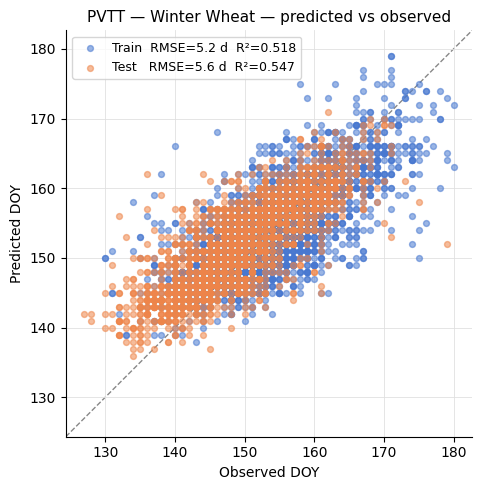

In [5]:
result_pvtt = SingleTargetRegression.run(
    model         = pvtt,
    dataset_train = ds_trn,
    dataset_test  = ds_tst,
    target_fn     = target_fn,
    run_name      = 'pvtt_wheat',
)
m_pvtt = result_pvtt.compute_metrics()
fig = result_pvtt.plot_scatter(title='PVTT — Winter Wheat — predicted vs observed')
plt.show()

## 3. PVTT season dynamics

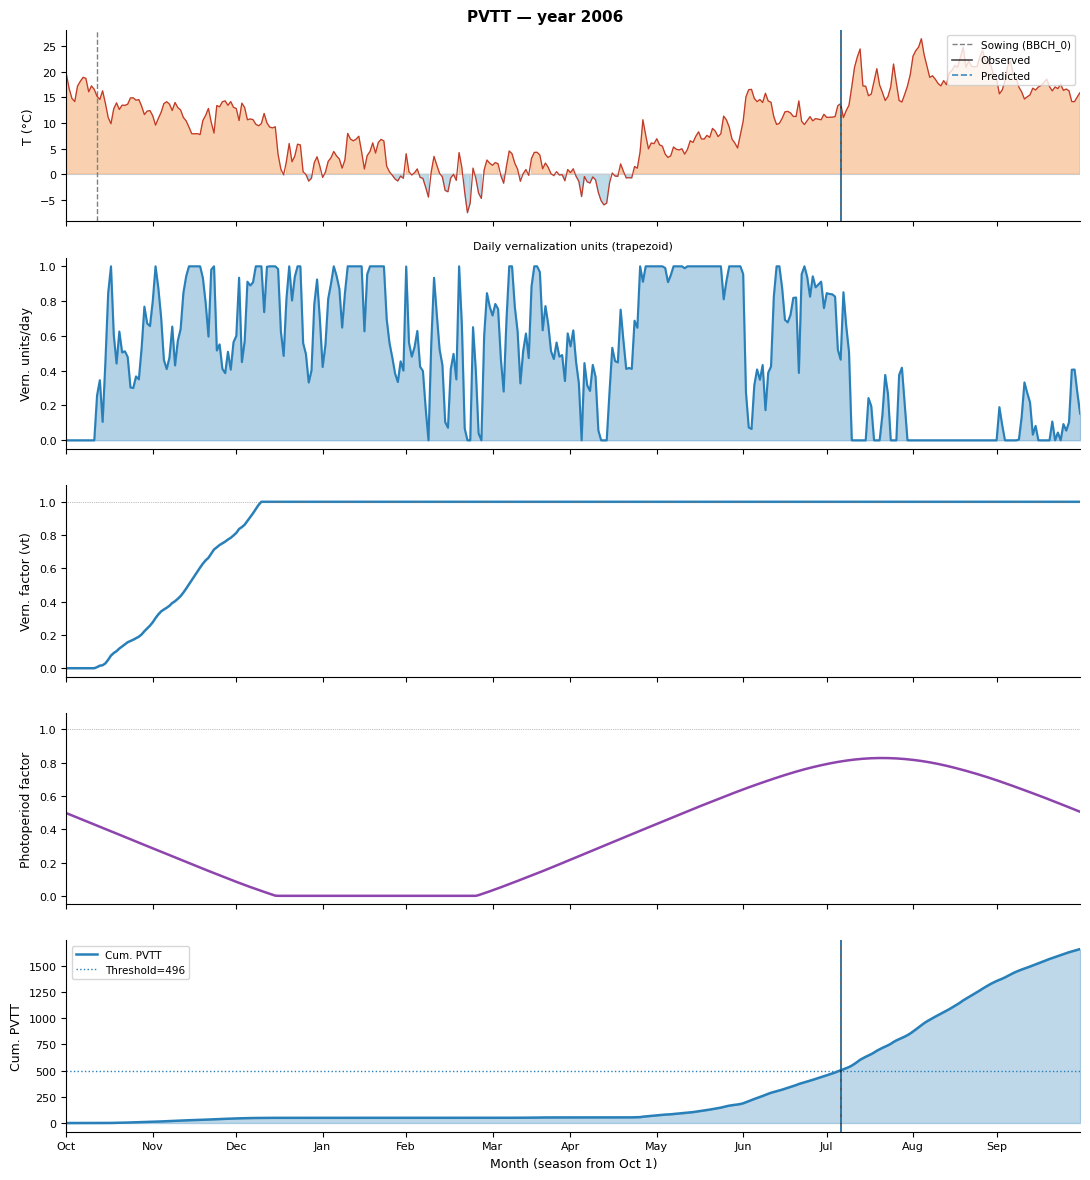

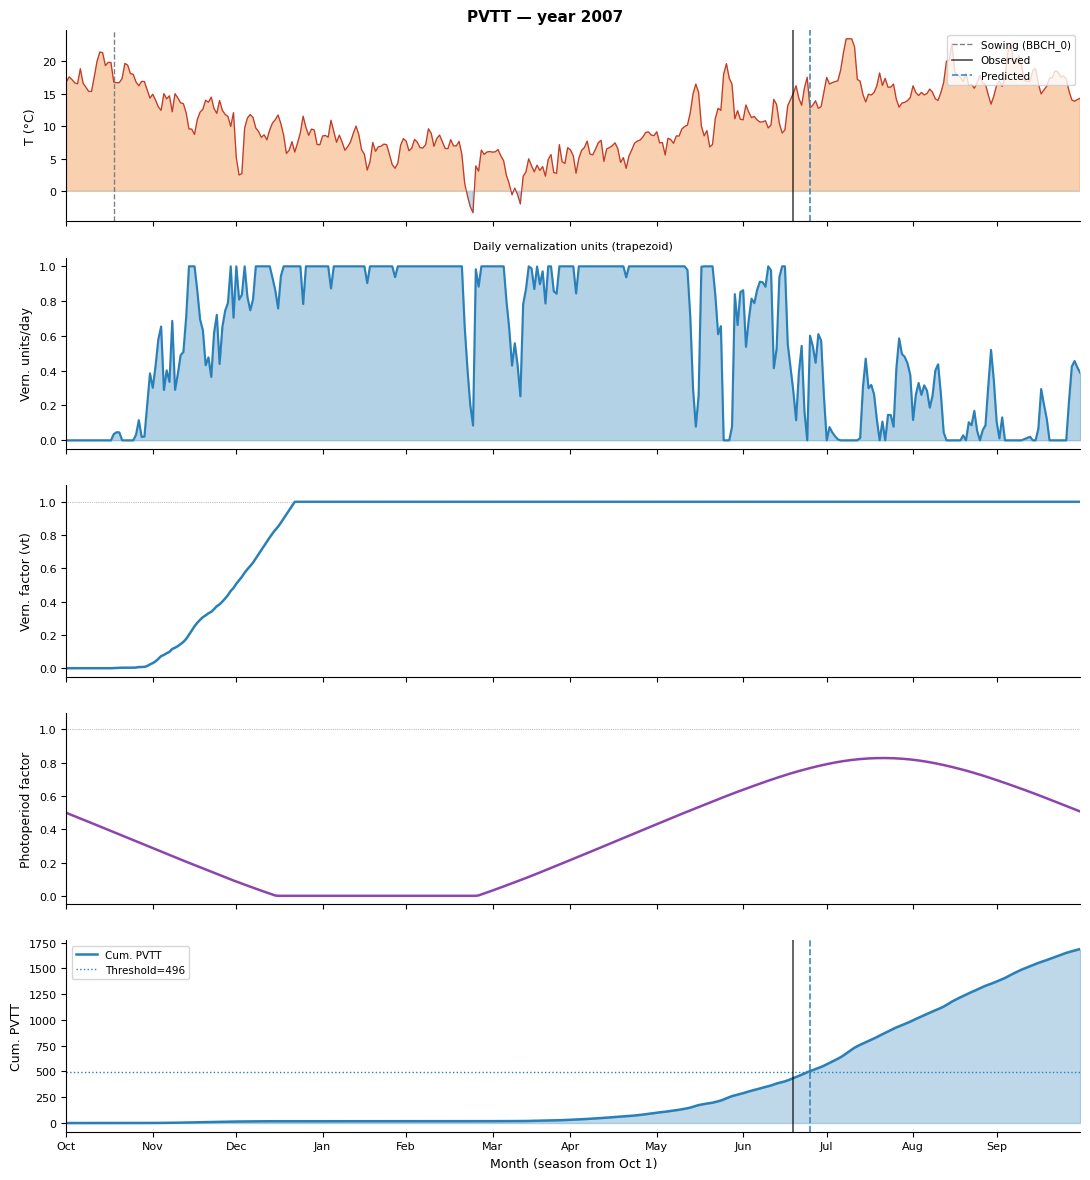

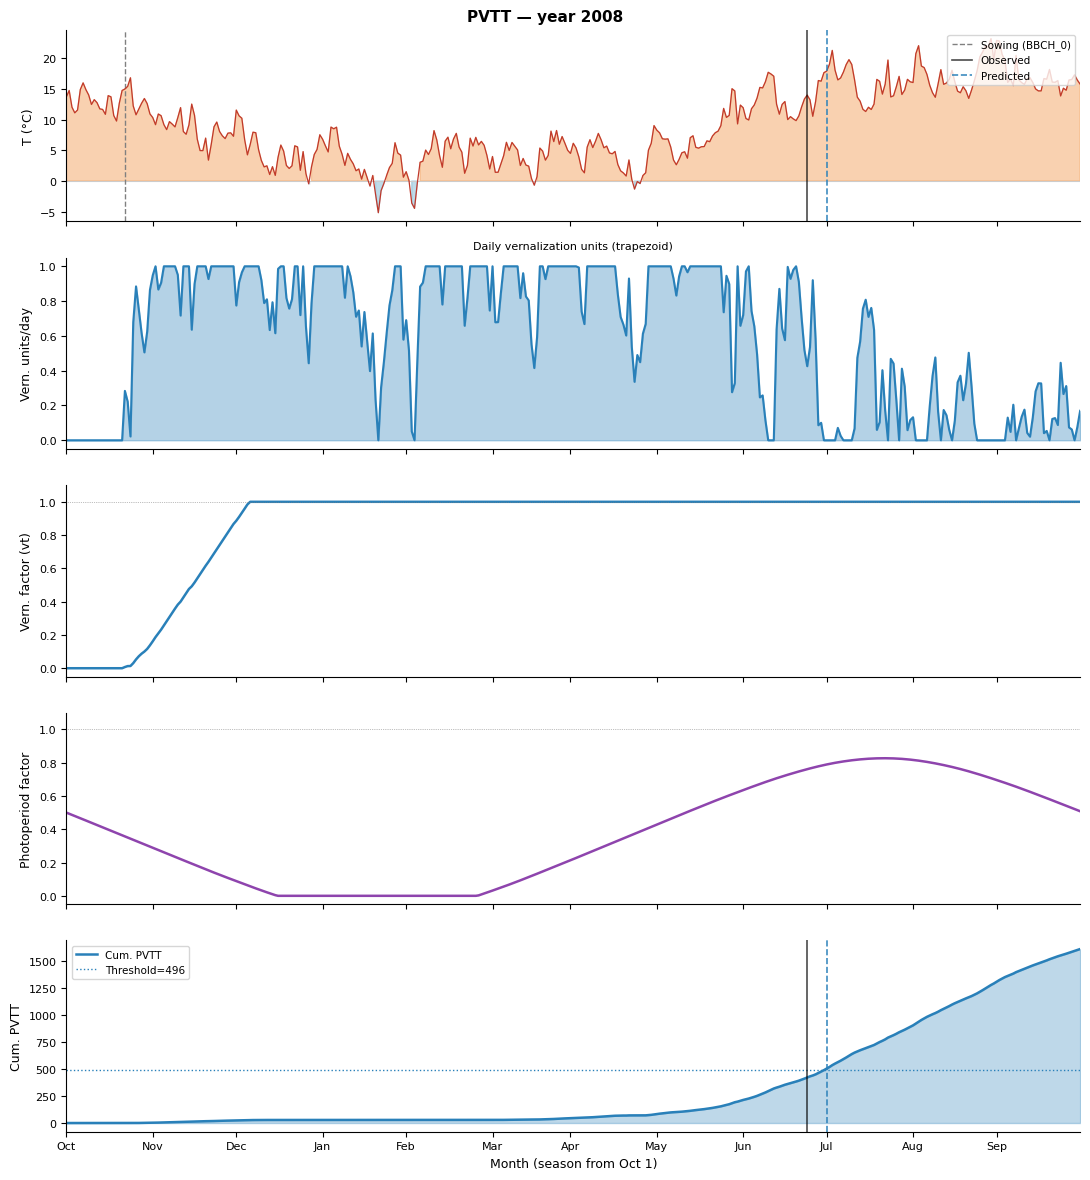

In [6]:
def plot_pvtt_season(model, sample, obs_ix=None, title=''):
    ts = sample[KEY_FEATURES]['temperature_2m_mean'].astype(float)
    ps = sample[KEY_FEATURES]['daylight_duration'].astype(float) / 3600.0
    n  = len(ts)
    days = np.arange(n)
    sow_ix = int(sample[KEY_OBSERVATIONS_INDEX][SOW_KEY])
    mask   = create_left_mask_np(n, sow_ix)

    vu = func_vernalization_unit(ts) * mask
    vt = func_vernalization_tres(vu.cumsum(), threshold=model.threshold_vern)
    pf = func_photoperiod_factor(ps, p_base=model.p_base, p_sat=model.p_saturation)
    gdu = func_growing_degree_units_2(ts, t_base=model.t_base,
                                      t_limit=model.t_limit, t_upper=model.t_upper)
    pvtt_daily = gdu * mask * vt * pf
    pvtt_cum   = pvtt_daily.cumsum()

    _, info = model.predict(sample)
    pred_ix = info['ix']
    color = MODEL_COLORS['PVTT']

    fig, axes = plt.subplots(5, 1, figsize=(11, 12), sharex=True)
    if title:
        fig.suptitle(title, fontsize=11, fontweight='bold')

    ax = axes[0]
    ax.axhline(0, color=PALETTE['zero'], lw=0.8)
    ax.axvline(sow_ix, color='grey', lw=1.0, ls='--', label='Sowing (BBCH_0)')
    ax.fill_between(days, ts, 0, where=(ts>=0), color=PALETTE['temp_warm'])
    ax.fill_between(days, ts, 0, where=(ts<0),  color=PALETTE['temp_cold'])
    ax.plot(days, ts, color=PALETTE['temp_line'], lw=0.9)
    if obs_ix is not None:
        ax.axvline(obs_ix, color='black', lw=1.2, ls='-', alpha=0.7, label='Observed')
    ax.axvline(pred_ix, color=color, lw=1.2, ls='--', alpha=0.9, label='Predicted')
    _style_ax(ax, n, ylabel='T (°C)')
    ax.legend(fontsize=7.5, loc='upper right')

    ax = axes[1]
    ax.fill_between(days, vu, color=color, alpha=0.35)
    ax.plot(days, vu, color=color, lw=1.5)
    _style_ax(ax, n, ylabel='Vern. units/day')
    ax.set_title('Daily vernalization units (trapezoid)', fontsize=8)

    ax = axes[2]
    ax.plot(days, vt, color=color, lw=1.8)
    ax.axhline(1.0, color='grey', lw=0.5, ls=':')
    _style_ax(ax, n, ylabel='Vern. factor (vt)')
    ax.set_ylim(-0.05, 1.1)

    ax = axes[3]
    ax.plot(days, pf, color='#8e44ad', lw=1.8)
    ax.axhline(1.0, color='grey', lw=0.5, ls=':')
    _style_ax(ax, n, ylabel='Photoperiod factor')
    ax.set_ylim(-0.05, 1.1)

    ax = axes[4]
    ax.fill_between(days, pvtt_cum, color=color, alpha=0.3)
    ax.plot(days, pvtt_cum, color=color, lw=1.8, label='Cum. PVTT')
    ax.axhline(model.threshold_pvtt, color=color, lw=1.0, ls=':',
               label=f'Threshold={model.threshold_pvtt:.0f}')
    if obs_ix is not None:
        ax.axvline(obs_ix, color='black', lw=1.2, ls='-', alpha=0.7)
    ax.axvline(pred_ix, color=color, lw=1.2, ls='--', alpha=0.9)
    _style_ax(ax, n, ylabel='Cum. PVTT', xlabel=True)
    ax.legend(fontsize=7.5)

    plt.tight_layout()
    plt.show()


for year in years_to_show:
    sample = pick_sample(ds_tst, year)
    obs_date = sample['observations'][OBS_KEY]
    obs_ix   = int((np.datetime64(obs_date, 'D')
                    - np.datetime64(sample['season_start'], 'D'))
                   / np.timedelta64(1, 'D'))
    plot_pvtt_season(pvtt, sample, obs_ix=obs_ix, title=f'PVTT — year {year}')

## 4. Wheat Hybrid model

Uses a TTCNN with **two output channels**, each accumulated from sowing and
soft-thresholded. The heading probability is the product of both:

    ps = SoftThreshold(cumsum_0) × SoftThreshold(cumsum_1)

This encodes the same two-stage requirement as PVTT — both accumulators must
be satisfied — while letting the network learn what each stage captures from
temperature and daylight features.

In [7]:
WHEAT_KWARGS = dict(
    data_keys        = ['temperature_2m_mean', 'daylight_duration'],
    hidden_size      = 32,
    kernel_size      = 7,
    num_layers       = 4,
    use_dilations    = False,
    learn_thresholds = True,
)

wheat, wheat_fit_info = WheatHybridModel.fit(
    target_fn        = target_fn,
    dataset          = ds_trn,
    model_kwargs     = WHEAT_KWARGS,
    num_epochs       = 1000,
    batch_size       = 512,
    val_period       = 10,
    optimizer        = 'adam',
    optimizer_kwargs = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-3,
    early_stopping_rerun     = True,
    device  = DEVICE,
    verbose = True,
)
print('WheatHybrid training complete.')

WheatHybridModel epoch [    1/1000] lr=1.00e-03 loss=1.59199: 100%|██████████| 6/6 [00:00<00:00, 11.62it/s]
WheatHybridModel epoch [    2/1000] lr=1.00e-03 loss=0.21503: 100%|██████████| 6/6 [00:00<00:00, 13.10it/s]
WheatHybridModel epoch [    3/1000] lr=1.00e-03 loss=0.20864: 100%|██████████| 6/6 [00:00<00:00, 12.78it/s]
WheatHybridModel epoch [    4/1000] lr=1.00e-03 loss=0.25368: 100%|██████████| 6/6 [00:00<00:00, 13.05it/s]
WheatHybridModel epoch [    5/1000] lr=1.00e-03 loss=0.18998: 100%|██████████| 6/6 [00:00<00:00, 12.80it/s]
WheatHybridModel epoch [    6/1000] lr=1.00e-03 loss=0.08970: 100%|██████████| 6/6 [00:00<00:00, 13.17it/s]
WheatHybridModel epoch [    7/1000] lr=1.00e-03 loss=0.09173: 100%|██████████| 6/6 [00:00<00:00, 13.29it/s]
WheatHybridModel epoch [    8/1000] lr=1.00e-03 loss=0.08594: 100%|██████████| 6/6 [00:00<00:00, 12.97it/s]
WheatHybridModel epoch [    9/1000] lr=1.00e-03 loss=0.07407: 100%|██████████| 6/6 [00:00<00:00, 13.01it/s]
WheatHybridModel epoch [   1

WheatHybrid training complete.


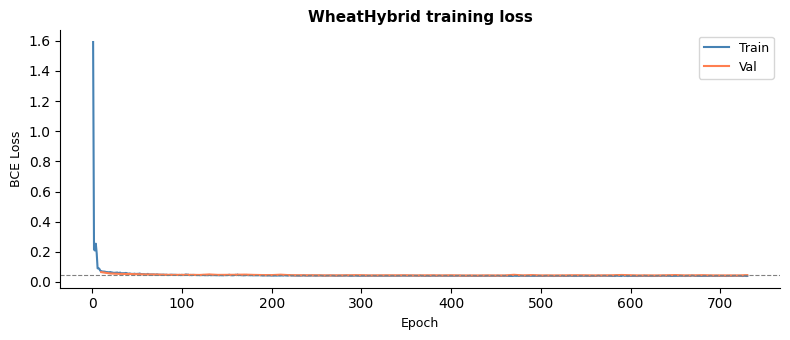

Learned channel-0 threshold: 0.466 (norm.) ≈ 170.3 acc. units
Learned channel-1 threshold: 0.465 (norm.) ≈ 169.7 acc. units


In [8]:
epochs   = [e['epoch'] for e in wheat_fit_info['epochs']]
trn_loss = [e['loss']  for e in wheat_fit_info['epochs']]
val_ep   = [e['epoch'] for e in wheat_fit_info['epochs'] if 'val' in e]
val_loss = [e['val']['loss'] for e in wheat_fit_info['epochs'] if 'val' in e]

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(epochs, trn_loss, label='Train', color='steelblue', lw=1.5)
if val_loss:
    ax.plot(val_ep, val_loss, label='Val', color='coral', lw=1.5)
    ax.axhline(min(val_loss), color='grey', ls='--', lw=0.8)
ax.set_xlabel('Epoch', fontsize=9)
ax.set_ylabel('BCE Loss', fontsize=9)
ax.set_title('WheatHybrid training loss', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

th0 = wheat._th0.threshold.item()
th1 = wheat._th1.threshold.item()
print(f'Learned channel-0 threshold: {th0:.3f} (norm.) ≈ {th0 * 365:.1f} acc. units')
print(f'Learned channel-1 threshold: {th1:.3f} (norm.) ≈ {th1 * 365:.1f} acc. units')

## 5. Evaluate and compare

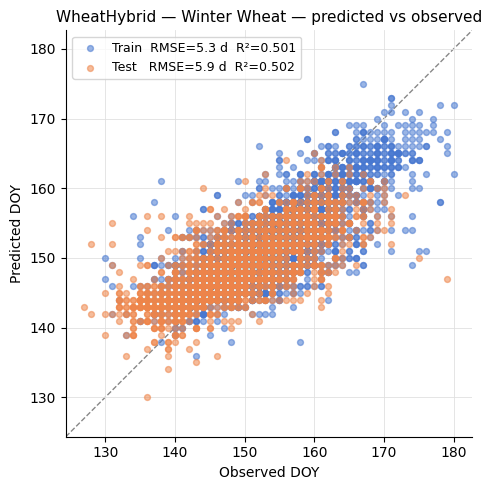

N  RMSE   MAE  Bias     R²
Model       Split                               
PVTT        train  3537  5.17  3.93 -0.09  0.518
            test   1747  5.62  4.32  2.45  0.547
WheatHybrid train  3537  5.26  4.07 -2.02  0.501
            test   1747  5.89  4.54 -0.35  0.502

In [9]:
result_wheat = SingleTargetRegression.run(
    model         = wheat,
    dataset_train = ds_trn,
    dataset_test  = ds_tst,
    target_fn     = target_fn,
    run_name      = 'wheat_hybrid',
)
fig = result_wheat.plot_scatter(title='WheatHybrid — Winter Wheat — predicted vs observed')
plt.show()

m_wheat = result_wheat.compute_metrics()
rows = []
for name, m in [('PVTT', m_pvtt), ('WheatHybrid', m_wheat)]:
    for split in ('train', 'test'):
        rows.append({
            'Model': name, 'Split': split,
            'N':    m[split]['n'],
            'RMSE': round(m[split]['rmse'], 2),
            'MAE':  round(m[split]['mae'],  2),
            'Bias': round(m[split]['bias'], 2),
            'R²':   round(m[split]['r2'],   3),
        })
pd.DataFrame(rows).set_index(['Model', 'Split'])

## 6a. Learned TTCNN response — temperature × daylight

Evaluate the TTCNN at steady state on a grid of constant-temperature,
constant-daylight sequences to map the learned 2D response surface for each channel.
The product `c0 × c1` is what ultimately gates heading probability.

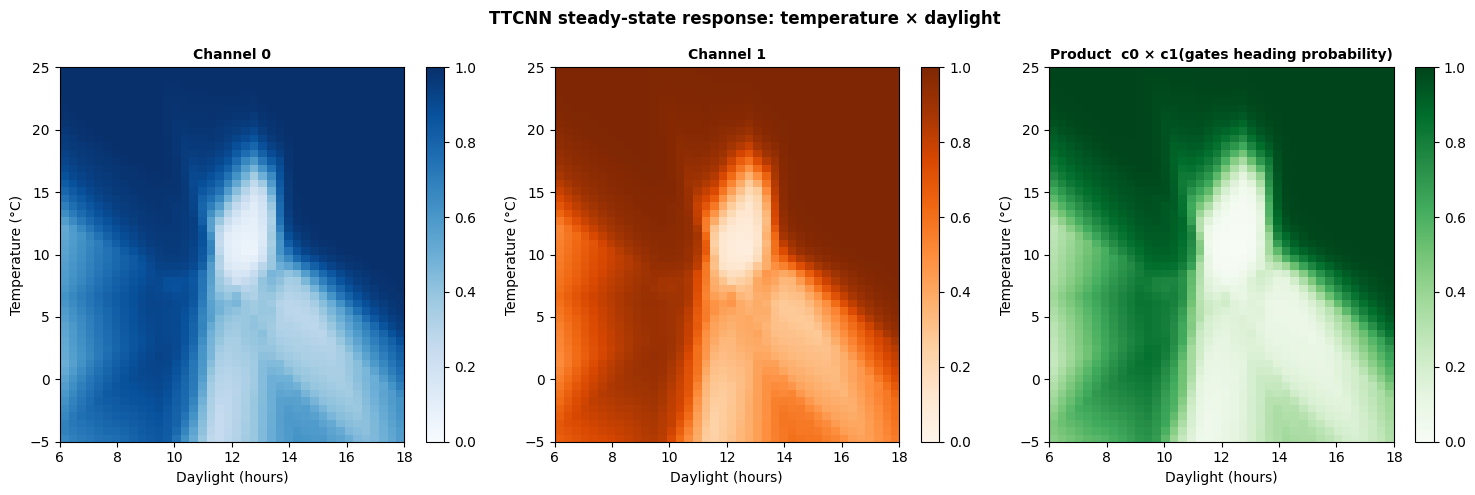

In [10]:
@torch.no_grad()
def plot_ttcnn_response_2d(model, t_range=(-5, 25), d_range=(6, 18),
                            n_t=50, n_d=40, seq_len=60):
    """2D heatmap of TTCNN steady-state response over temperature × daylight grid.

    Feeds constant-valued sequences long enough to exceed the receptive field,
    then reads the output at the last timestep (steady state).
    """
    model.eval()
    device = next(model.parameters()).device

    t_mean, t_std = model._feature_statistics['temperature_2m_mean']
    d_mean, d_std = model._feature_statistics['daylight_duration']

    t_vals = np.linspace(t_range[0], t_range[1], n_t)
    d_vals = np.linspace(d_range[0], d_range[1], n_d)  # hours

    t_norm = (t_vals - t_mean) / t_std
    d_norm = (d_vals * 3600.0 - d_mean) / d_std  # convert h → s before normalising

    # Build (n_t * n_d, 2, seq_len) batch of constant sequences
    T_g, D_g = np.meshgrid(t_norm, d_norm, indexing='ij')  # (n_t, n_d)
    T_flat = torch.tensor(T_g.reshape(-1), dtype=torch.float32, device=device)
    D_flat = torch.tensor(D_g.reshape(-1), dtype=torch.float32, device=device)

    x = torch.stack([
        T_flat.unsqueeze(1).expand(-1, seq_len),
        D_flat.unsqueeze(1).expand(-1, seq_len),
    ], dim=1)  # (n_t*n_d, 2, seq_len)

    out = model._ttcnn(x)           # (n_t*n_d, 2, seq_len)
    c0 = out[:, 0, -1].cpu().numpy().reshape(n_t, n_d)
    c1 = out[:, 1, -1].cpu().numpy().reshape(n_t, n_d)
    prod = c0 * c1

    extent = [d_range[0], d_range[1], t_range[0], t_range[1]]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle('TTCNN steady-state response: temperature × daylight',
                 fontsize=12, fontweight='bold')

    for ax, data, title, cmap in zip(
        axes,
        [c0,      c1,      prod],
        ['Channel 0', 'Channel 1', 'Product  c0 × c1(gates heading probability)'],
        ['Blues', 'Oranges', 'Greens'],
    ):
        im = ax.imshow(data, origin='lower', aspect='auto', extent=extent,
                       cmap=cmap, vmin=0, vmax=1)
        plt.colorbar(im, ax=ax)
        ax.set_xlabel('Daylight (hours)', fontsize=10)
        ax.set_ylabel('Temperature (°C)', fontsize=10)
        ax.set_title(title, fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()


plot_ttcnn_response_2d(wheat)

## 6. WheatHybrid season dynamics

For each held-out season: temperature, the two channel contributions,
the two cumulative accumulators, and the resulting heading probability.

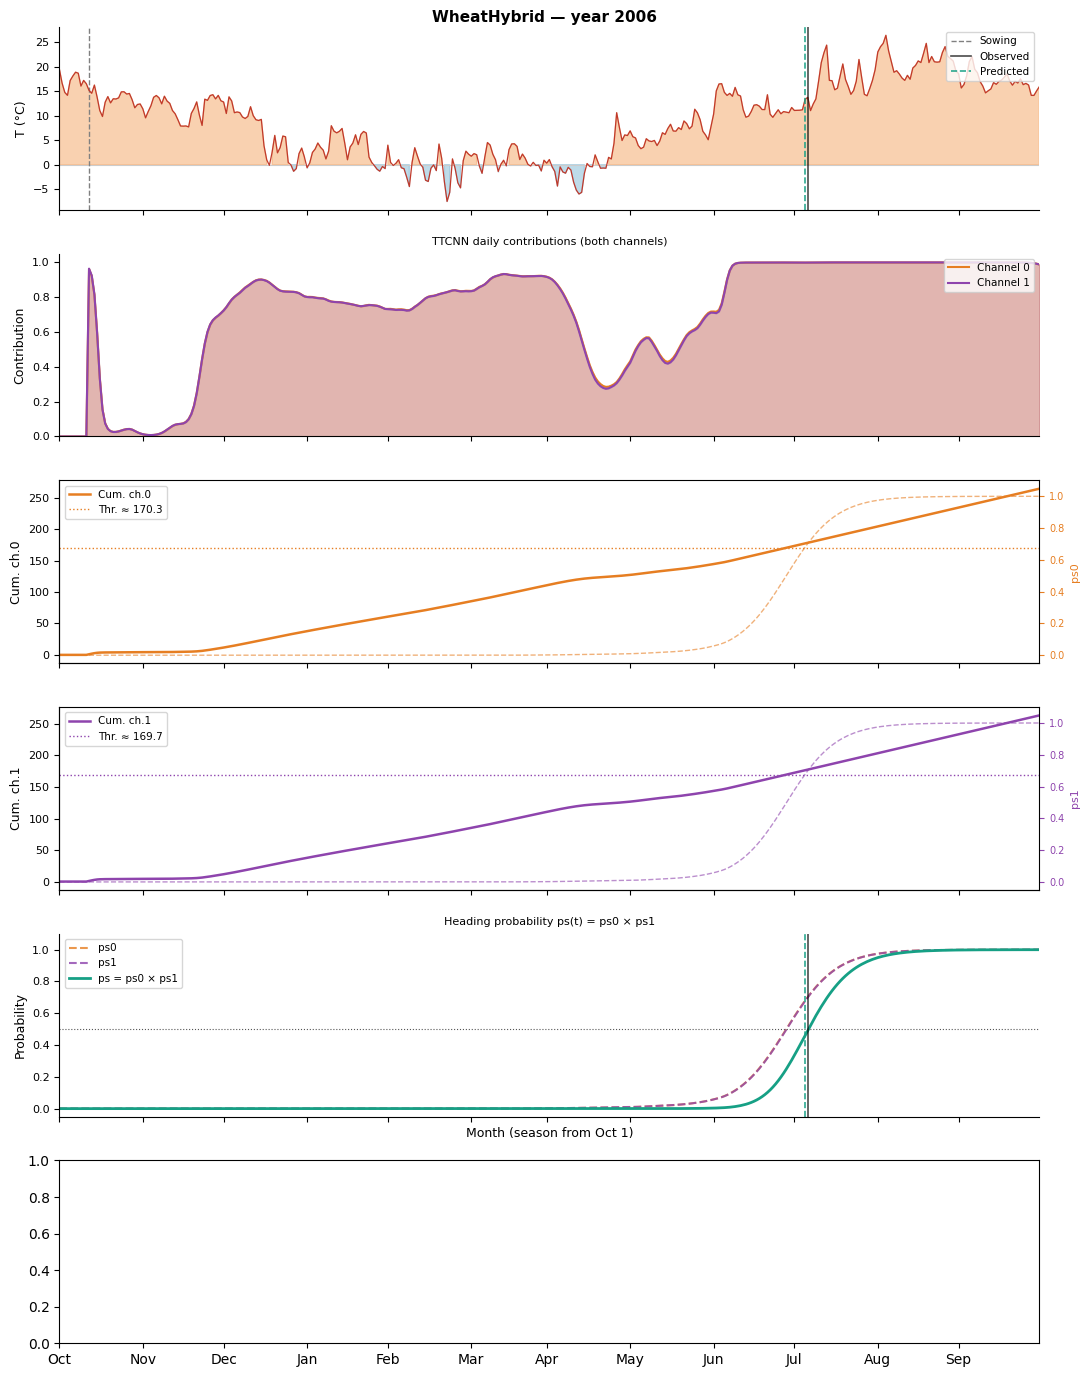

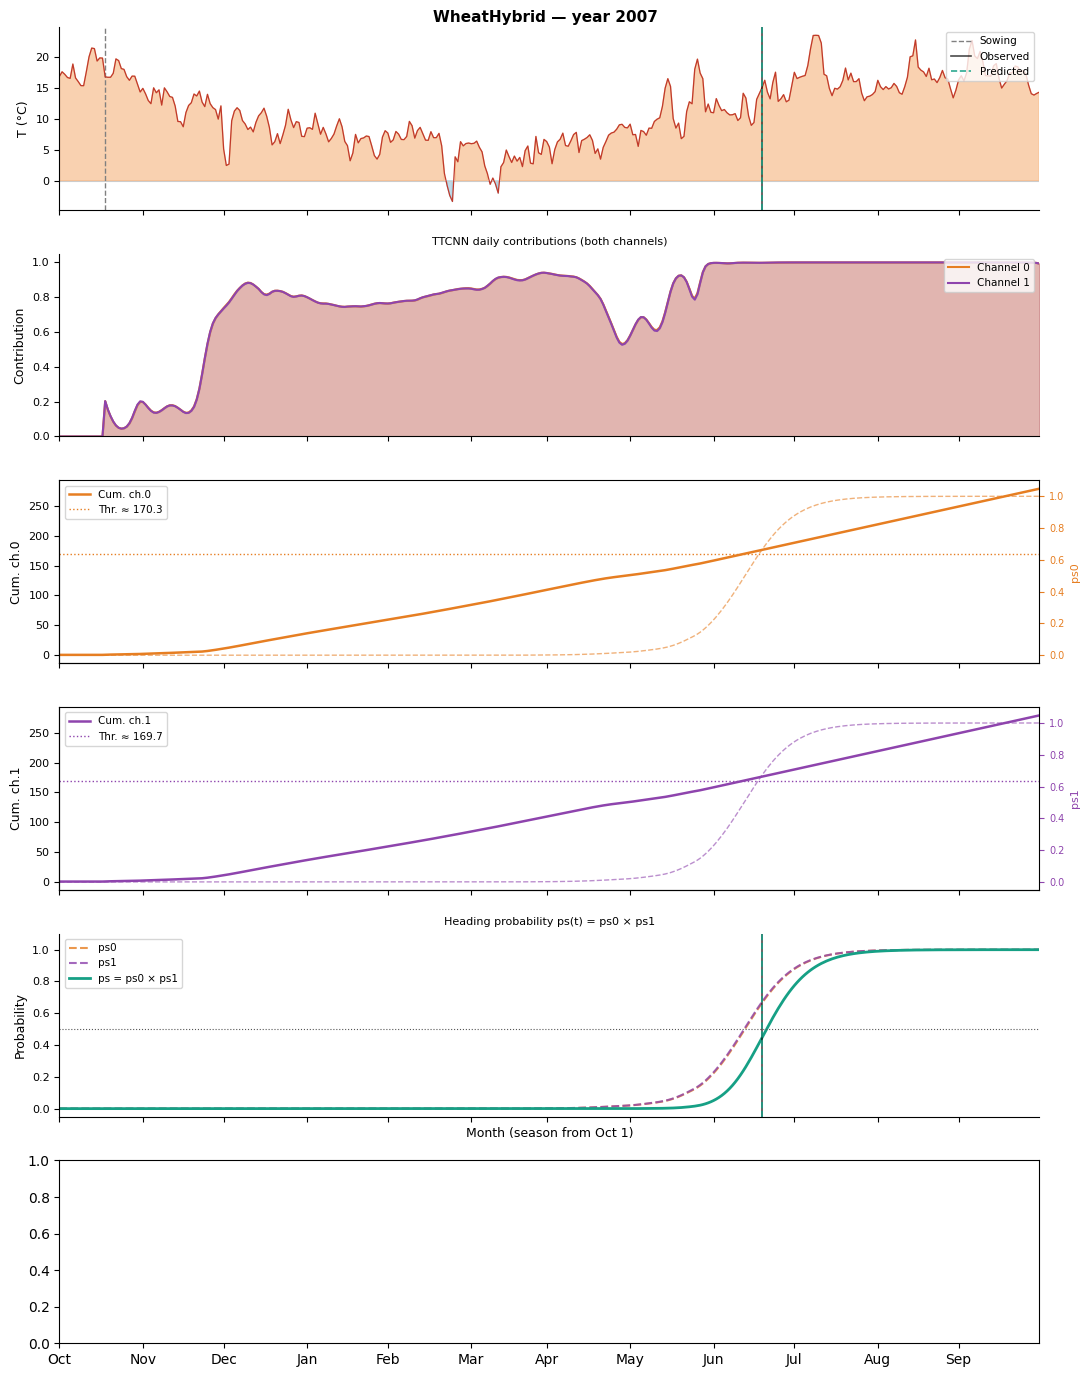

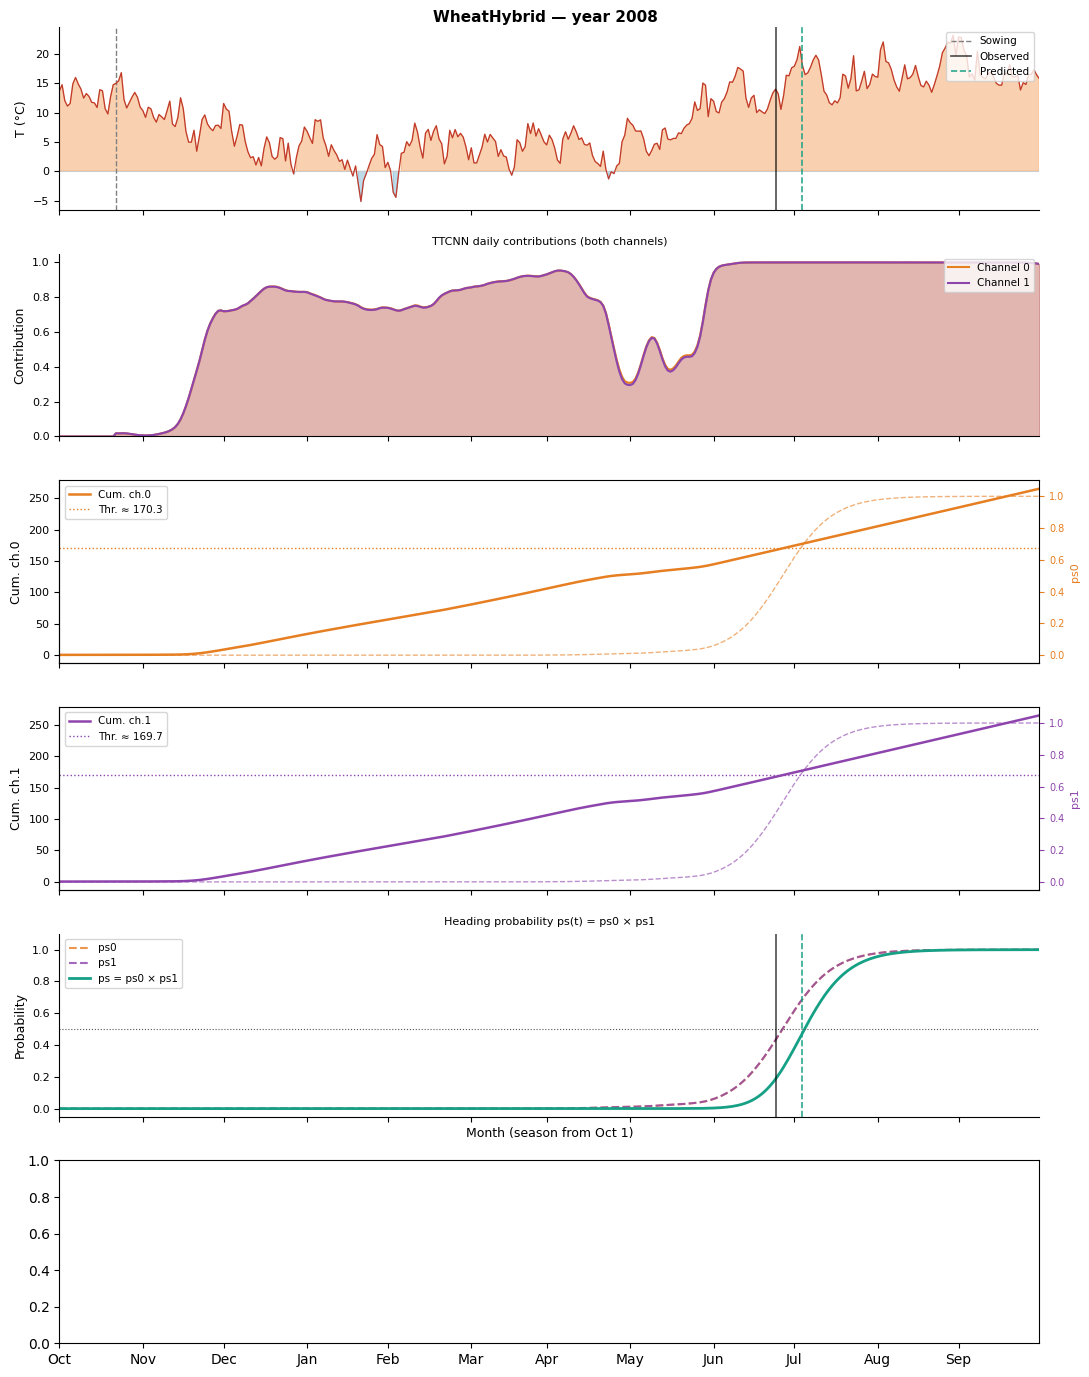

In [11]:
@torch.no_grad()
def plot_wheat_season(model, sample, obs_ix=None, title=''):
    model.eval()
    device = next(model.parameters()).device
    t_sample = WheatHybridModel.cast_to_tensor(sample, device=device)
    batch    = WheatHybridModel.collate_fn([t_sample])
    ixs, info = model(batch)

    pred_ix = int(ixs[0].item() + 0.5)
    ts      = sample[KEY_FEATURES]['temperature_2m_mean'].astype(float)
    n       = len(ts)
    days    = np.arange(n)
    sow_ix  = int(sample[KEY_OBSERVATIONS_INDEX][SOW_KEY])

    c0  = info['c0'][0].cpu().numpy()
    c1  = info['c1'][0].cpu().numpy()
    cs0 = info['cs0'][0].cpu().numpy()
    cs1 = info['cs1'][0].cpu().numpy()
    ps0 = info['ps0'][0].cpu().numpy()
    ps1 = info['ps1'][0].cpu().numpy()
    ps  = info['ps'][0].cpu().numpy()

    th0 = model._th0.threshold.item()
    th1 = model._th1.threshold.item()

    color  = MODEL_COLORS['WheatHybrid']
    color0 = MODEL_COLORS['ch0']
    color1 = MODEL_COLORS['ch1']

    fig, axes = plt.subplots(6, 1, figsize=(11, 14), sharex=True)
    if title:
        fig.suptitle(title, fontsize=11, fontweight='bold')

    ax = axes[0]
    ax.axhline(0, color=PALETTE['zero'], lw=0.8)
    ax.axvline(sow_ix, color='grey', lw=1.0, ls='--', label='Sowing')
    ax.fill_between(days, ts, 0, where=(ts>=0), color=PALETTE['temp_warm'])
    ax.fill_between(days, ts, 0, where=(ts<0),  color=PALETTE['temp_cold'])
    ax.plot(days, ts, color=PALETTE['temp_line'], lw=0.9)
    if obs_ix is not None:
        ax.axvline(obs_ix, color='black', lw=1.2, ls='-', alpha=0.7, label='Observed')
    ax.axvline(pred_ix, color=color, lw=1.2, ls='--', alpha=0.9, label='Predicted')
    _style_ax(ax, n, ylabel='T (°C)')
    ax.legend(fontsize=7.5, loc='upper right')

    ax = axes[1]
    ax.fill_between(days, c0, color=color0, alpha=0.35)
    ax.plot(days, c0, color=color0, lw=1.5, label='Channel 0')
    ax.fill_between(days, c1, color=color1, alpha=0.20)
    ax.plot(days, c1, color=color1, lw=1.5, label='Channel 1')
    _style_ax(ax, n, ylabel='Contribution')
    ax.set_ylim(0, 1.05)
    ax.set_title('TTCNN daily contributions (both channels)', fontsize=8)
    ax.legend(fontsize=7.5, loc='upper right')

    ax = axes[2]
    ax.plot(days, cs0, color=color0, lw=1.8, label='Cum. ch.0')
    ax.axhline(th0 * 365, color=color0, lw=1.0, ls=':',
               label=f'Thr. ≈ {th0*365:.1f}')
    ax2 = ax.twinx()
    ax2.plot(days, ps0, color=color0, lw=1.0, ls='--', alpha=0.6)
    ax2.set_ylabel('ps0', fontsize=8, color=color0)
    ax2.set_ylim(-0.05, 1.1)
    ax2.tick_params(labelsize=7, colors=color0)
    _style_ax(ax, n, ylabel='Cum. ch.0')
    ax.legend(fontsize=7.5)

    ax = axes[3]
    ax.plot(days, cs1, color=color1, lw=1.8, label='Cum. ch.1')
    ax.axhline(th1 * 365, color=color1, lw=1.0, ls=':',
               label=f'Thr. ≈ {th1*365:.1f}')
    ax2 = ax.twinx()
    ax2.plot(days, ps1, color=color1, lw=1.0, ls='--', alpha=0.6)
    ax2.set_ylabel('ps1', fontsize=8, color=color1)
    ax2.set_ylim(-0.05, 1.1)
    ax2.tick_params(labelsize=7, colors=color1)
    _style_ax(ax, n, ylabel='Cum. ch.1')
    ax.legend(fontsize=7.5)

    ax = axes[4]
    ax.plot(days, ps0, color=color0, lw=1.5, ls='--', alpha=0.8, label='ps0')
    ax.plot(days, ps1, color=color1, lw=1.5, ls='--', alpha=0.8, label='ps1')
    ax.plot(days, ps,  color=color,  lw=2.0,                      label='ps = ps0 × ps1')
    ax.axhline(0.5, color=PALETTE['thresh'], lw=0.8, ls=':')
    if obs_ix is not None:
        ax.axvline(obs_ix, color='black', lw=1.2, ls='-', alpha=0.7)
    ax.axvline(pred_ix, color=color, lw=1.2, ls='--', alpha=0.9)
    _style_ax(ax, n, ylabel='Probability', xlabel=True)
    ax.set_ylim(-0.05, 1.1)
    ax.set_title('Heading probability ps(t) = ps0 × ps1', fontsize=8)
    ax.legend(fontsize=7.5, loc='upper left')

    plt.tight_layout()
    plt.show()


for year in years_to_show:
    sample = pick_sample(ds_tst, year)
    obs_date = sample['observations'][OBS_KEY]
    obs_ix   = int((np.datetime64(obs_date, 'D')
                    - np.datetime64(sample['season_start'], 'D'))
                   / np.timedelta64(1, 'D'))
    plot_wheat_season(wheat, sample, obs_ix=obs_ix,
                      title=f'WheatHybrid — year {year}')

## 7. Synthetic sensitivity sweep — winter temperature

Vary mean winter temperature with fixed spring conditions.
A model with the correct inductive bias should predict later heading
when winters are too warm (insufficient vernalization).

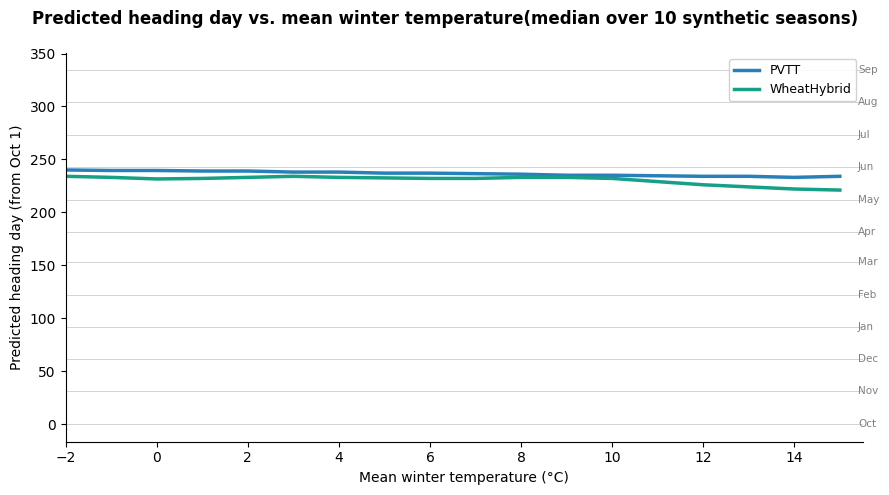

In [12]:
def _daylight_series(n=365):
    days = np.arange(n)
    return (12.0 - 4.0 * np.cos(2 * np.pi * (days - 81) / 365)) * 3600.0


def generate_wheat_sample(mean_winter_temp, mean_spring_temp=12.0,
                           noise_std=1.5, sow_ix=30, seed=0,
                           season_start=np.datetime64('1990-10-01')):
    rng = np.random.default_rng(seed)
    ts  = np.zeros(365)
    ts[0:sow_ix]   = 10.0
    ts[sow_ix:150] = mean_winter_temp
    ts[150:250]    = mean_spring_temp
    ts[250:365]    = 18.0
    ts += rng.normal(0, noise_std, 365)
    return {
        KEY_FEATURES: {
            'temperature_2m_mean': ts.astype(np.float32),
            'daylight_duration':   _daylight_series(365).astype(np.float32),
        },
        KEY_OBSERVATIONS_INDEX: {'BBCH_0': sow_ix},
        'season_start': np.datetime64(season_start) if isinstance(season_start, str) else season_start,
        'observations': {},
    }


WINTER_TEMPS = np.arange(-2, 16, 1.0)
N_SEEDS = 10
SOW_IX  = 30

pvtt_bloom  = []
wheat_bloom = []
wheat.eval()

for mw in WINTER_TEMPS:
    p_seeds, w_seeds = [], []
    for seed in range(N_SEEDS):
        sample = generate_wheat_sample(mean_winter_temp=mw, seed=seed, sow_ix=SOW_IX)
        _, info_p = pvtt.predict(sample)
        p_seeds.append(info_p['ix'])
        with torch.no_grad():
            t_s   = WheatHybridModel.cast_to_tensor(sample)
            batch = WheatHybridModel.collate_fn([t_s])
            ixs, _ = wheat(batch)
        w_seeds.append(int(ixs[0].item() + 0.5))
    pvtt_bloom.append(np.median(p_seeds))
    wheat_bloom.append(np.median(w_seeds))

pvtt_bloom  = np.array(pvtt_bloom)
wheat_bloom = np.array(wheat_bloom)

fig, ax = plt.subplots(figsize=(9, 5))
fig.suptitle('Predicted heading day vs. mean winter temperature'
             '(median over 10 synthetic seasons)',
             fontsize=12, fontweight='bold')

for doy, month in zip(_MONTH_STARTS, _MONTH_LABELS):
    ax.axhline(doy, color='lightgrey', lw=0.7, zorder=0)
    ax.text(15.4, doy, month, fontsize=7.5, va='center', color='grey')

valid_p = pvtt_bloom < 364
ax.plot(WINTER_TEMPS[valid_p], pvtt_bloom[valid_p],
        color=MODEL_COLORS['PVTT'], lw=2.5, label='PVTT')
valid_w = wheat_bloom < 364
ax.plot(WINTER_TEMPS[valid_w], wheat_bloom[valid_w],
        color=MODEL_COLORS['WheatHybrid'], lw=2.5, label='WheatHybrid')

ax.set_xlabel('Mean winter temperature (°C)', fontsize=10)
ax.set_ylabel('Predicted heading day (from Oct 1)', fontsize=10)
ax.legend(fontsize=9, framealpha=0.9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(-2, 15.5)
plt.tight_layout()
plt.show()